<a href="https://colab.research.google.com/github/devansh1201/Gen-Ai-Dl/blob/main/zeno_telent_assinment_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [4]:
df=pd.read_csv('/content/vgsales.csv')

In [5]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [6]:
df.isnull().sum()

,0
Rank,0
Name,0
Platform,0
Year,271
Genre,0
Publisher,58
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


In [10]:
X=df[['NA_Sales',	'EU_Sales'	,'JP_Sales'	,'Other_Sales'	,'Global_Sales']]

In [11]:
X

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,41.49,29.02,3.77,8.46,82.74
1,29.08,3.58,6.81,0.77,40.24
2,15.85,12.88,3.79,3.31,35.82
3,15.75,11.01,3.28,2.96,33.00
4,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...
16593,0.01,0.00,0.00,0.00,0.01
16594,0.01,0.00,0.00,0.00,0.01
16595,0.00,0.00,0.00,0.00,0.01
16596,0.00,0.01,0.00,0.00,0.01


In [12]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [13]:
X_scaled

array([[50.48050838, 57.13692978, 11.93805759, 44.60608534, 52.86402505],
       [35.28443669,  6.7941883 , 21.76729621,  3.82822442, 25.53250298],
       [19.08427325, 25.19778483, 12.00272364, 17.29711476, 22.69002469],
       ...,
       [-0.32408584, -0.29020692, -0.25149161, -0.25486439, -0.33919426],
       [-0.32408584, -0.27041811, -0.25149161, -0.25486439, -0.33919426],
       [-0.31184082, -0.29020692, -0.25149161, -0.25486439, -0.33919426]])

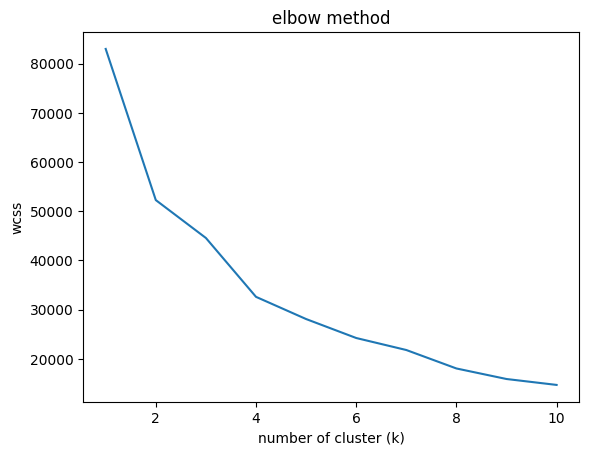

In [14]:
wcss=[]
for k in range(1,11):
  kmeans=KMeans(n_clusters=k,random_state=42)
  kmeans.fit(X_scaled)
  wcss.append(kmeans.inertia_)

plt.plot(range(1,11),wcss)
plt.xlabel('number of cluster (k)')
plt.ylabel('wcss')
plt.title('elbow method')
plt.show()

In [15]:
kmeans=KMeans(n_clusters=4,random_state=42)
labels=kmeans.fit_predict(X_scaled)

In [16]:
df['Cluster']=labels

In [17]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Cluster
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,2
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,1
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,1
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,1
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,1


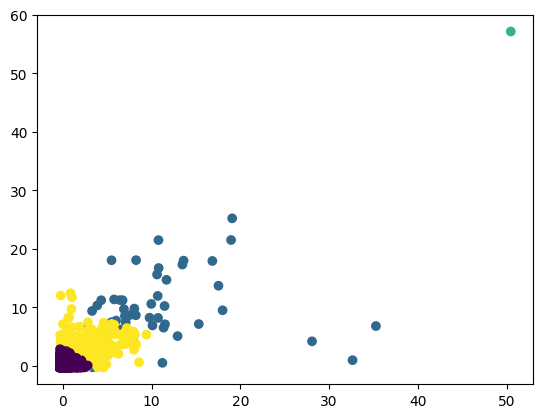

In [19]:
plt.scatter(X_scaled[:,0],X_scaled[:,1],c=labels)